# [참고: YOLO 프로젝트 전체개요]
**YOLO 학습을 위해 반드시 거쳐야 할 핵심 흐름**은 다음과 같습니다.

1. **데이터 이해 (Data Understanding & EDA)**
2. **데이터 수집 (Data Acquisition):** Oxford-IIIT Pet 데이터셋 다운로드 (Images & Annotations).
3. **데이터 전처리 (Preprocessing & Conversion):**  확인된 데이터 특성에 맞춰 전처리(Resize, Augmentation) 전략 수립.
    - Oxford 데이터셋은 기본적으로 Pascal VOC(xml) 포맷입니다.
    - YOLO 포맷(txt, normalized xywh)으로 변환해야 합니다.
    - Class Mapping(품종 이름 → ID) 파일 생성.
4. **데이터 분할 (Data Splitting):** Train / Validation / Test 셋으로 폴더 구조 분리.
5. **모델 학습 (Training):** YOLO 모델(v8, v10 등) 선정 및 `data.yaml` 설정 후 학습.
6. **성능 평가 (Evaluation):** mAP, Confusion Matrix 확인.
7. **추론 및 시각화 (Inference):** 테스트 이미지로 결과 확인.

## SSD학습 이미지
Single Shot MultiBox Detector(SSD)는 객체 탐지 모델 중 하나로, 그리드 셀(grid cell)과 앵커 박스(anchor box)를 사용하는 방식으로 다양한 크기의 객체를 탐지합니다. SSD 모델을 학습하려면, 이미지에 대한 입력 데이터와 함께 객체의 위치 정보를 포함하는 주석(annotations)이 필요합니다. 이 주석 정보는 보통 바운딩 박스의 좌표와 클래스 레이블을 포함합니다.

- SSD 학습 이미지 포맷 구성 요소
- 이미지 파일:
  - 입력 이미지 파일은 일반적인 이미지 형식(JPEG, PNG 등)을 사용합니다.

- 바운딩 박스:
- 각 이미지에 대해 객체의 바운딩 박스 좌표가 필요합니다.
- 좌표는 보통 [xmin, ymin, xmax, ymax] 형식으로 제공되며, 이미지의 픽셀 단위일 수 있습니다.
- SSD 모델은 입력 이미지 크기를 고정된 크기로 리사이즈하여 학습하기 때문에, 바운딩 박스를 정규화(0~1 범위로 변환)하는 경우도 많습니다.


- 클래스 레이블:
  - 각 바운딩 박스에 할당되는 클래스 레이블이 필요합니다.
  - 레이블은 정수형 ID를 사용하여 각 클래스(예: 고양이, 개, 차 등)를 식별합니다.

- 일반적인 주석 형식
  - Pascal VOC 형식 (XML)
  - COCO 형식 (JSON)
  - CSV 또는 TXT 파일로 커스터마이즈

### 데이터 이해 (Data Understanding & EDA)
- 옥스포드 대학교 VGG(Visual Geometry Group)에서 만든 **반려동물 이미지 데이터셋**
- 37종의 강아지와 고양이 품종을 분류하거나, 특히 **이미지 세그멘테이션(Segmentation)** 모델을 학습시킬 때 표준처럼 사용되는 중요한 자료 (bouning box를 제공함으로 객체인식도 가능함)
- **카테고리:** 총 37개 품종 (강아지 25종, 고양이 12종)
- **데이터 양:** 품종당 약 200장, 총 **7,349장**의 이미지
- **특징:** 이미지가 각도(Pose), 조명, 크기(Scale) 면에서 매우 다양하게 구성되어 있어 실전 학습용으로 좋음

| **구분** | **설명** | **YOLO 학습 시 주의사항** |
| --- | --- | --- |
| **두 가지 Annotation 존재** | 이 데이터셋은 `Segmentation Mask`(픽셀 단위 분류)와 `Bounding Box`(네모 박스) 정보가 섞여 있거나 폴더가 다릅니다. | YOLO를 사용하려면 **`xmls` 폴더의 Bounding Box 정보만 필터링**해서 사용해야 합니다. Segmentation 데이터는 YOLO 학습에 직접 사용 불가입니다. |
| **Fine-grained Classification (세부 분류)** | 단순 "개/고양이" 수준이 아니라 **특정 품종 간의 미세 차이**를 구분해야 하는 데이터셋입니다. | 육안으로도 구분이 어려운 품종이 섞여 있으므로, **클래스 수가 많을수록 더 많은 데이터와 적절한 augmentation이 필요**합니다. |
| **Head vs Body** | 일부 이미지는 전신이 아닌 **얼굴(Head) 중심 샷**이 존재합니다. | Bounding Box가 **얼굴만 포함하는지, 몸 전체를 포함하는지** 일관성이 중요한데, 이게 섞여 있으면 YOLO가 객체 크기 분포를 혼동할 수 있습니다. 사전 점검이 필요합니다. |


# 데이터 탐색 및 불러오기
# xml데이터구조
- Oxford-IIIT Pet Dataset의 XML 데이터는 각 이미지에 대한 주석(annotation) 정보를 포함하고 있으며, 객체 탐지(Object Detection) 및 이미지 분류(Classification) 작업에서 사용할 수 있습니다. XML 파일의 구조와 주요 특징은 다음과 같습니다:

- 파일 구조:

  - 각 XML 파일은 Pascal VOC 형식을 따르고 있으며, 각 파일은 하나의 이미지에 대응됩니다.
  - XML 파일에는 이미지에 대한 메타데이터와 객체의 바운딩 박스 정보가 포함되어 있습니다.
  - XML 파일의 주요 구성 요소:

          <annotation>: 루트 엘리먼트로, 각 XML 파일의 최상위 태그입니다.
          <folder>: 이미지가 저장된 폴더의 이름입니다.
          <filename>: 이미지 파일의 이름입니다.
          <size>: 이미지의 크기를 포함하는 태그입니다. 하위 요소로 <width>, <height>, <depth>가 있습니다.
          <object>: 이미지 내에 객체를 정의하는 반복 가능한 요소입니다. 하나의 이미지에 여러 객체가 있을 수 있습니다.
          <name>: 객체의 클래스 이름 (예: 고양이, 개의 특정 품종).
          <bndbox>: 객체의 바운딩 박스 정보를 포함하며, 하위 요소로 <xmin>, <ymin>, <xmax>, <ymax> 등이 포함됩니다. 이들은 이미지 내에서 객체의 좌표를 나타냅니다.
- 활용 가능한 작업:
  - 객체 탐지: 바운딩 박스 정보를 사용하여 이미지 내에서 특정 객체를 인식하고, 모델을 훈련하기 위해 사용됩니다.
  - 품종 분류: 데이터셋의 클래스 명 정보를 활용하여, 고양이 및 개 뷰티의 품종 분류 작업에 사용할 수 있습니다.

In [3]:
#----------------------------------------
# 코렙캐시로 다운로드
# kagglehub는 기본 캐시를 /root/.cache 에 둬서 # 추가 설정 없이 바로 다운로드가 가능
# /content 보다 root권한 디렉토리가  파일 쓰기/읽기 속도가 빠르고 안정적
# YOLO 학습이나 EDA 할 때 파일 경로만 맞춰주면 바로 사용 가능
# 영구 저장용은 아니지만 빠르게 실행할수 있는 경로임
#------------------------------------------
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zippyz/cats-and-dogs-breeds-classification-oxford-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-and-dogs-breeds-classification-oxford-dataset' dataset.
Path to dataset files: /kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset


In [ ]:
#------------------------
# [추가] 한국어 번역기
# ---------------------------
!pip install googletrans==4.0.0-rc1

In [13]:
#--------------------------
# [추가] 코렙 터미널에서 Path to dataset files 확인
# cd 경로명 -> ls
# 상위5개만 보기: ls | head -n 5
#-----------------------------------
# 파일 경로 설정
# 필요한 라이브러리 설치 (코렙 환경에서)
from googletrans import Translator

# 파일 경로 설정
readme_path = '/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/annotations/annotations/README'

# 파일 읽기 및 번역 및 출력
try:
    with open(readme_path, 'r') as file:
        readme_content = file.read()
        print("Original content:\n", readme_content)

    # 번역기 초기화
    translator = Translator()

    # 번역 수행 (텍스트가 짧으면 한 번에 번역이 가능하지만, 긴 경우에는 chunk로 나누어야 함)
    translated_content = translator.translate(readme_content, src='en', dest='ko').text
    print("\nTranslated content:\n", translated_content)

except FileNotFoundError:
    print("README 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
except Exception as e:
    print("번역 중 오류가 발생했습니다: ", str(e))



Original content:
 OXFORD-IIIT PET Dataset
-----------------------
Omkar M Parkhi, Andrea Vedaldi, Andrew Zisserman and C. V. Jawahar

We have created a 37 category pet dataset with roughly 200 images for each class. 
The images have a large variations in scale, pose and lighting. All images have an 
associated ground truth annotation of breed, head ROI, and pixel
level trimap segmentation.

Contents:
--------
trimaps/ 	Trimap annotations for every image in the dataset
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
		Each entry in the file is of following nature:
		Image CLASS-ID SPECIES BREED ID
		ID: 1:37 Class ids
		SPECIES: 1:Cat 2:Dog
		BREED ID: 1-25:Cat 1:12:Dog
		All images with 1st letter as captial are cat images while
		images with small first letter are dog images.
trainval.txt	Files describing splits used in the paper.However,
test.txt	you are e

In [16]:
#------------------------------------
# [추가] list.txt 파일 내용  먼저 확인하기
#
#----------------------------------------

list_path = '/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/annotations/annotations/list.txt'

try:
    with open(list_path, 'r') as file:
        lines = file.readlines()
        print("list.txt 파일 내용 (예시):")
        for line in lines[:10]:  # 상위 10줄만 예시로 출력
            print(line.strip())
except FileNotFoundError:
    print("list.txt 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

list.txt 파일 내용 (예시):
#Image CLASS-ID SPECIES BREED ID
#ID: 1:37 Class ids
#SPECIES: 1:Cat 2:Dog
#BREED ID: 1-25:Cat 1:12:Dog
#All images with 1st letter as captial are cat images
#images with small first letter are dog images
Abyssinian_100 1 1 1
Abyssinian_101 1 1 1
Abyssinian_102 1 1 1
Abyssinian_103 1 1 1


In [ ]:
#-----------------------------
# [추가] 위의 자료 이해
#  Abyssinian_100 1 1 1
# Abyssinian_100: 이미지를 파일 이름으로, Abyssinian이라는 고양이 품종의 100번째 이미지
# 첫 번째 1 (클래스 ID):  전체 데이터셋에서 Abyssinian이라는 품종이 첫 번째 클래스임을 뜻함
# 두 번째 1 (종 ID):1은 고양이, 2는 강아지, 데이터셋의 관례에 따라 고양이와 개를 구분
# 세 번째 1 (품종 ID):품종 내에서 더 세부적으로 구분하기 위한 ID로, Abyssinian 고양이를 의미합니다.
#                      고양이 품종 중에서 Abyssinian에 해당합니다
#------------------------------

# 참고 (아비시니안 고양이 특징)
# 아비시니안 고양이는 짧고 윤기 있는 털을 가지고 있으며, 털빛이 빛에 반사되어 매우 매끄럽고
# 화려하게 보입니다.
# 털 색상은 일반적으로 따뜻한 갈색 톤이며, 검은 줄무늬 같은 티킹(ticking)이 특징입니다.
# 성격:
# 매우 호기심이 많고 활발한 품종으로 잘 알려져 있습니다.
# 사교적이며 사람과의 상호작용을 매우 좋아합니다

In [15]:
#-------------------------------
# [추가] trainval.txt 에 대하여
# 이미지 파일 이름: 데이터셋에 포함된 각 이미지의 이름.
# 클래스 ID: 이미지가 속하는 클래스 (고양이 또는 개의 특정 품종)의 식별자입니다.
# 종: 1은 고양이를 의미하고, 2는 개를 의미합니다.
# 품종 ID: 고양이 또는 개 품종의 세부 식별자입니다.
#------------------------------

trainval_path = '/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/annotations/annotations/trainval.txt'

try:
    with open(trainval_path, 'r') as file:
        trainval_content = file.readlines()
        print("trainval.txt 파일 내용 (상위 몇 줄):")
        for line in trainval_content[:5]:  # 상위 10줄만 예시로 출력
            print(line.strip())
except FileNotFoundError:
    print("trainval.txt 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

trainval.txt 파일 내용 (상위 몇 줄):
Abyssinian_100 1 1 1
Abyssinian_101 1 1 1
Abyssinian_102 1 1 1
Abyssinian_103 1 1 1
Abyssinian_104 1 1 1


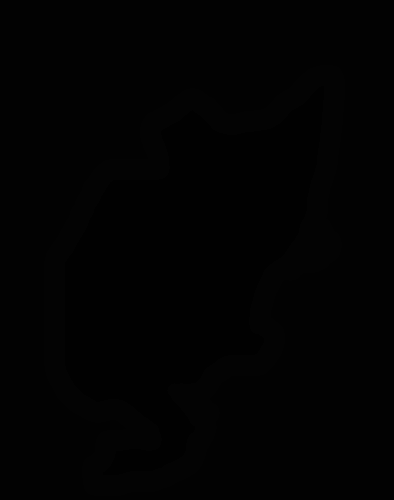

In [17]:
#----------------------------------
# [추가] 샘플이미지보기
# 터미널에서
# ls | sort | head -n 5  로 5개리스트만 보기
#----------------------------------

from PIL import Image
sample='/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/'
sample+='annotations/annotations/trimaps/Abyssinian_100.png'
img=Image.open(sample)
img

# [추가]_위의검정색 화면 설명
trimaps는 주로 이미지 분할(Image Segmentation)을 위해 사용되는 주석 파일입니다. Oxford-IIIT Pet Dataset의 trimaps 폴더에 있는 파일들은 각 이미지에 대한 픽셀 레벨의 분할 정보를 포함하고 있습니다. 이를 통해 각 픽셀이 전경, 배경, 또는 분류되지 않은 구역 중 어디에 속하는지를 구분할 수 있습니다.

- Trimaps의 구성:
1: 전경(Foreground):
- 실제로 동물의 몸체가 있는 부분을 나타냅니다. 이 영역은 특정한 색상 값으로 표시됩니다.

2: 배경(Background):
- 동물이 아닌 나머지 이미지의 영역을 나타냅니다. 일반적으로 다른 고유의 색상 값으로 지정됩니다.

3: 분류되지 않음(Unlabeled):
- 이 영역은 보통 그 어떤 카테고리에도 속하지 않는 픽셀들이며, 때로는 경계 영역 등으로 사용될 수 있습니다.

- 검정색만 보이는 이유:
  검정색만 보이는 이유는 이미지 뷰어가 trimaps 파일 안의 특정 색상 값만을 추출했기 때문일 수 있습니다. 보통 trimaps 파일 내의 값은 1, 2, 3으로 매핑되어 있고, 컬러로 보이지 않을 수 있습니다. 이는 보통 그레이스케일 색조 값으로 피상적으로만 보이기 때문입니다.

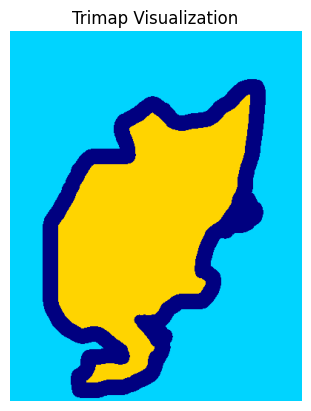

In [19]:
#-----------------------
# 추가_이건 세그멘테이션용
#--------------------------
import cv2
import matplotlib.pyplot as plt

sample='/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/'
sample+='annotations/annotations/trimaps/Abyssinian_100.png'
# 이미지 읽기 (Grayscale)
trimap = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)

# 각 값(1, 2, 3)을 구분하여 색상화
colored_trimap = cv2.applyColorMap(trimap * 85, cv2.COLORMAP_JET)  # 85 to scale 0-3 up to 0-255

# 이미지 시각화
plt.imshow(colored_trimap)
plt.title('Trimap Visualization')
plt.axis('off')
plt.show()

In [34]:
#----------------------------------
# [추가] xml샘플보기
# 상위 5개리스트만 보기 / 터미널에서
# ls | sort | head -n 5
#----------------------------------
import xml.dom.minidom
sample='/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/'
sample+='annotations/annotations/xmls/Abyssinian_100.xml'


with open(sample, "r", encoding="utf-8") as f:
    content = f.read()

dom = xml.dom.minidom.parseString(content)
pretty_xml = dom.toprettyxml()

print(pretty_xml)

<?xml version="1.0" ?>
<annotation>
	<folder>OXIIIT</folder>
	<filename>Abyssinian_100.jpg</filename>
	<source>
		<database>OXFORD-IIIT Pet Dataset</database>
		<annotation>OXIIIT</annotation>
		<image>flickr</image>
	</source>
	<size>
		<width>394</width>
		<height>500</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>cat</name>
		<pose>Frontal</pose>
		<truncated>0</truncated>
		<occluded>0</occluded>
		<bndbox>
			<xmin>151</xmin>
			<ymin>71</ymin>
			<xmax>335</xmax>
			<ymax>267</ymax>
		</bndbox>
		<difficult>0</difficult>
	</object>
</annotation>



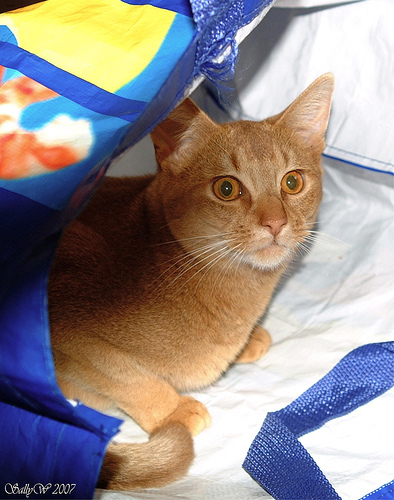

In [35]:
#----------------------------------
# [추가] images폴더의 샘플이미지보기
# 상위 5개리스트만 보기 / 터미널에서
# ls | sort | head -n 5
#----------------------------------
from PIL import Image
sample='/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/'
sample+='images/images/Abyssinian_100.jpg'
img=Image.open(sample)
img

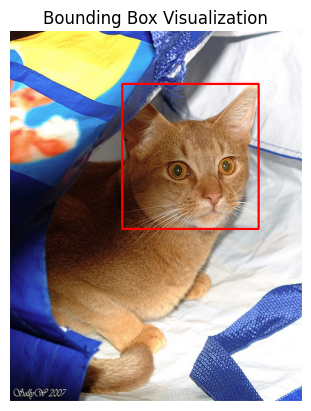

In [37]:
#------------------------
# 추가: 바운딩 박스 그리기
#----------------------------
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

# XML 파일 경로 및 이미지 파일 경로 설정
xml_path = '/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/annotations/annotations/xmls/Abyssinian_100.xml'
image_path = '/kaggle/input/cats-and-dogs-breeds-classification-oxford-dataset/images/images/Abyssinian_100.jpg'

# XML 파일 파싱
tree = ET.parse(xml_path)
root = tree.getroot()

# 바운딩 박스 좌표 추출
bndbox = root.find('.//bndbox')
xmin = int(bndbox.find('xmin').text)
ymin = int(bndbox.find('ymin').text)
xmax = int(bndbox.find('xmax').text)
ymax = int(bndbox.find('ymax').text)

# 이미지 읽기
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 바운딩 박스 그리기
cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)  # 파란색, 두께 2

# 이미지 시각화
plt.imshow(image)
plt.title('Bounding Box Visualization')
plt.axis('off')
plt.show()

In [38]:
import torch

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

# 파일 경로 설정
trainval_file_path = os.path.join(path, "annotations", "annotations", "trainval.txt")
test_file_path = os.path.join(path, "annotations", "annotations", "test.txt")

# 이미지, Annotation 경로 설정
image_dir = os.path.join(path, "images", "images")
xml_dir = os.path.join(path, "annotations", "annotations", "xmls")

# Train/Validation 파일 읽기
df_trainval = pd.read_csv(trainval_file_path, sep="\s+", header=None)
df_trainval.columns = ["Image", "ClassID", "Species", "BreedID"]

# Test 파일 읽기
df_test = pd.read_csv(test_file_path, sep="\s+", header=None)
df_test.columns = ["Image", "ClassID", "Species", "BreedID"]

# 데이터 크기 확인
print(f"Train/Validation 데이터 수: {len(df_trainval)}")
print(f"Test 데이터 수: {len(df_test)}")

# Annotation 개수 확인
xml_files = [file for file in os.listdir(xml_dir) if file.endswith(".xml")]
print(f"XML 파일 개수: {len(xml_files)}")

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3296508719.py:15: SyntaxWarning: invalid escape sequence '\s'
  df_trainval = pd.read_csv(trainval_file_path, sep="\s+", header=None)
/tmp/ipython-input-3296508719.py:19: SyntaxWarning: invalid escape sequence '\s'
  df_test = pd.read_csv(test_file_path, sep="\s+", header=None)


Train/Validation 데이터 수: 3680
Test 데이터 수: 3669
XML 파일 개수: 3686


In [39]:
print(df_trainval.shape)
df_trainval.head()

(3680, 4)


,Image,ClassID,Species,BreedID
0,Abyssinian_100,1,1,1
1,Abyssinian_101,1,1,1
2,Abyssinian_102,1,1,1
3,Abyssinian_103,1,1,1
4,Abyssinian_104,1,1,1


In [40]:
print(df_test.shape)
df_test.head()

(3669, 4)


,Image,ClassID,Species,BreedID
0,Abyssinian_201,1,1,1
1,Abyssinian_202,1,1,1
2,Abyssinian_204,1,1,1
3,Abyssinian_205,1,1,1
4,Abyssinian_206,1,1,1


In [41]:
df_trainval['Species'].value_counts()

,count
Species,
2,2492
1,1188


In [42]:
df_test['Species'].value_counts()

,count
Species,
2,2486
1,1183


In [43]:
# Train과 Validation에 사용될 이미지 파일 이름 리스트 생성
trainval_list = df_trainval['Image'].tolist()

# Test에 사용될 이미지 파일 이름 리스트 생성
test_list = df_test['Image'].tolist()

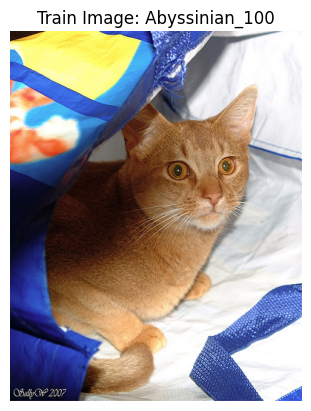

In [44]:
# Train 데이터에서 예제 이미지 불러오기
train_example_image_name = df_trainval["Image"].iloc[0]
train_image_path = os.path.join(image_dir, f"{train_example_image_name}.jpg")

# 이미지 읽기
train_image = cv2.imread(train_image_path)
train_image = cv2.cvtColor(train_image, cv2.COLOR_BGR2RGB)

# Train 이미지 출력
plt.imshow(train_image)
plt.title(f"Train Image: {train_example_image_name}")
plt.axis("off")
plt.show()

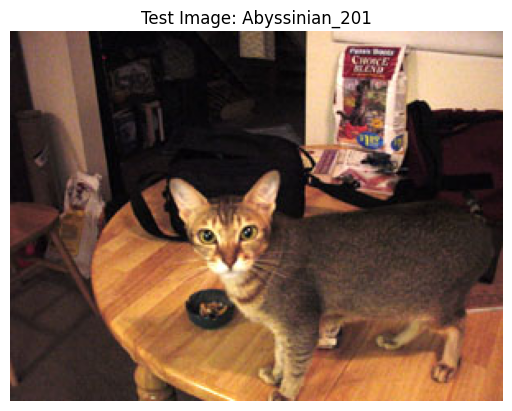

In [45]:
# Test 데이터에서 예제 이미지 불러오기
test_example_image_name = df_test["Image"].iloc[0]
test_image_path = os.path.join(image_dir, f"{test_example_image_name}.jpg")

# 이미지 읽기
test_image = cv2.imread(test_image_path)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

# Test 이미지 출력
plt.imshow(test_image)
plt.title(f"Test Image: {test_example_image_name}")
plt.axis("off")
plt.show()

In [46]:
# XML 파일 이름 가져오기 (확장자 제거)
xml_list = [os.path.splitext(file)[0] for file in os.listdir(xml_dir) if file.endswith(".xml")]

# Train 이미지에 대해 XML 파일이 없는 경우 확인
missing_xml = [image for image in trainval_list if image not in xml_list]

# Train 이미지에 대해 XML 파일이 있는 경우 확인
trainval_list = [image for image in trainval_list if image in xml_list]

# 결과 출력
print(f"XML 파일이 없는 Train 이미지 수: {len(missing_xml)}")
print(missing_xml)

XML 파일이 없는 Train 이미지 수: 9
['Abyssinian_104', 'Bengal_111', 'samoyed_10', 'Bengal_175', 'Egyptian_Mau_14', 'Egyptian_Mau_156', 'Egyptian_Mau_186', 'Ragdoll_199', 'saint_bernard_15']


In [47]:
import xml.etree.ElementTree as ET

# 예제 XML 파일 경로
example_xml_file = os.path.join(xml_dir, xml_files[0])

# XML 파일 읽기 및 파싱
tree = ET.parse(example_xml_file)
root = tree.getroot()

# 재귀적으로 모든 태그와 데이터 출력 함수
def print_all_elements(element, indent=""):
    print(f"{indent}{element.tag}: {element.text}")
    for child in element:
        print_all_elements(child, indent + "  ")

# XML 구조 탐색
print_all_elements(root)

annotation: None
  folder: OXIIIT
  filename: staffordshire_bull_terrier_165.jpg
  source: None
    database: OXFORD-IIIT Pet Dataset
    annotation: OXIIIT
    image: flickr
  size: None
    width: 500
    height: 375
    depth: 3
  segmented: 0
  object: None
    name: dog
    pose: Frontal
    truncated: 0
    occluded: 0
    bndbox: None
      xmin: 165
      ymin: 73
      xmax: 356
      ymax: 235
    difficult: 0


In [48]:
# XML 파일에서 Bounding Box와 클래스 정보 추출
for obj in root.findall("object"):
    class_name = obj.find("name").text  # 클래스 이름
    bndbox = obj.find("bndbox")
    x_min = int(bndbox.find("xmin").text)
    y_min = int(bndbox.find("ymin").text)
    x_max = int(bndbox.find("xmax").text)
    y_max = int(bndbox.find("ymax").text)

    print(f"Class: {class_name}, Bounding Box: ({x_min}, {y_min}, {x_max}, {y_max})")

Class: dog, Bounding Box: (165, 73, 356, 235)


In [49]:
# 모든 XML 파일 처리
annotations = []

for xml_file in xml_files:
    xml_path = os.path.join(xml_dir, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_name = root.find("filename").text  # 이미지 파일 이름

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        bndbox = obj.find("bndbox")
        x_min = int(bndbox.find("xmin").text)
        y_min = int(bndbox.find("ymin").text)
        x_max = int(bndbox.find("xmax").text)
        y_max = int(bndbox.find("ymax").text)

        annotations.append({
            "image": image_name,
            "class": class_name,
            "bbox": [x_min, y_min, x_max, y_max]
        })

# Object Detection 시각화

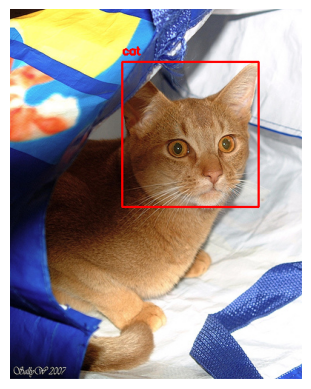

In [ ]:
# Train 데이터에서 예제 이미지 불러오기
train_example_image_name = df_trainval["Image"].iloc[0]
train_image_path = os.path.join(image_dir, f"{train_example_image_name}.jpg")

# 이미지 읽기
image = cv2.imread(train_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 해당 이미지의 어노테이션 가져오기
annotations = [anno for anno in annotations if anno["image"] == f"{train_example_image_name}.jpg"]

# Bounding Box 그리기
for anno in annotations:
    x_min, y_min, x_max, y_max = anno["bbox"]
    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)  # 빨간색 박스
    cv2.putText(image, anno["class"], (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# 시각화
plt.imshow(image)
plt.axis("off")
plt.show()

# 데이터셋 준비

In [50]:
from torchvision.transforms import v2

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
    ]
)

In [51]:
from PIL import Image
from torch.utils.data import Dataset

class VOCDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, classes, image_list, transforms=None):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.classes = classes
        self.transforms = transforms
        self.image_files = image_list # 미리 필터링된 유효한 이미지 파일 리스트

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 이미지 및 XML 파일 경로 설정
        image_file = self.image_files[idx] + ".jpg"
        annotation_file = self.image_files[idx] + ".xml"
        image_path = os.path.join(self.image_dir, image_file)
        annotation_path = os.path.join(self.annotation_dir, annotation_file)

        # 이미지 로드
        image = Image.open(image_path).convert("RGB")

        # 어노테이션 로드
        boxes = []
        labels = []
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            class_name = obj.find("name").text
            if class_name not in self.classes:
                continue
            labels.append(self.classes.index(class_name))

            bndbox = obj.find("bndbox")
            x_min = int(bndbox.find("xmin").text)
            y_min = int(bndbox.find("ymin").text)
            x_max = int(bndbox.find("xmax").text)
            y_max = int(bndbox.find("ymax").text)
            boxes.append([x_min, y_min, x_max, y_max])

        # Tensor로 변환
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        # Transform 적용
        if self.transforms:
            image, boxes, labels = self.transforms(image, boxes, labels)

        target = {"boxes": boxes, "labels": labels}
        return image, target

In [52]:
class TestDataset(Dataset):
    def __init__(self, image_dir, image_list, transforms=None):
        self.image_dir = image_dir
        self.transforms = transforms
        self.image_files = image_list  # 테스트 이미지 리스트 (확장자 없음)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 이미지 파일 경로
        image_file = self.image_files[idx] + ".jpg"
        image_path = os.path.join(self.image_dir, image_file)

        # 이미지 로드
        image = Image.open(image_path).convert("RGB")

        # Transform 적용
        if self.transforms:
            image = self.transforms(image)

        return image, self.image_files[idx]  # 이미지와 파일 이름 반환

In [53]:
from sklearn.model_selection import train_test_split

# Train/Validation 분리 (trainval_list에서 80% Train, 20% Validation으로 나눔)
train_list, valid_list = train_test_split(trainval_list, test_size=0.3, random_state=42)

# 결과 확인
print(f"Train 이미지 수: {len(train_list)}")
print(f"Validation 이미지 수: {len(valid_list)}")
print(f"Test 이미지 수: {len(test_list)}")

Train 이미지 수: 2569
Validation 이미지 수: 1102
Test 이미지 수: 3669


In [57]:
from torch.utils.data import DataLoader

# 클래스 정의
classes = ["background", "dog", "cat"]

# Train Dataset
train_dataset = VOCDataset(
    image_dir=image_dir,
    annotation_dir=xml_dir,
    classes=classes,
    image_list=train_list,  # Train 리스트 사용
    transforms=transform
)

# Validation Dataset
valid_dataset = VOCDataset(
    image_dir=image_dir,
    annotation_dir=xml_dir,
    classes=classes,
    image_list=valid_list,  # Validation 리스트 사용
    transforms=transform
)

# Test Dataset 생성
test_dataset = TestDataset(
    image_dir=image_dir,  # 테스트 이미지 디렉토리
    image_list=test_list,       # 테스트 이미지 리스트 (확장자 없는 이름)
    transforms=transform  # 필요하면 Transform 적용
)


# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# 데이터 크기 출력
print(f"Train 데이터셋 크기: {len(train_dataset)}")
print(f"Validation 데이터셋 크기: {len(valid_dataset)}")
print(f"Test 데이터셋 크기: {len(test_dataset)}")


Train 데이터셋 크기: 2569
Validation 데이터셋 크기: 1102
Test 데이터셋 크기: 3669


# SSD 모델 준비

- SSD 모델 리스트와 특징
1. SSD300 with VGG16 Backbone
- 모델:
  - ssd300_vgg16: VGG16을 백본(backbone)으로 사용한 SSD 모델입니다.
  - SSD300_VGG16_Weights: 사전 학습된 가중치를 로딩할 때 사용할 수 있습니다.

- 특징:
  - 네트워크 구조: VGG16 기반으로 구성된 백본을 사용하여 피처 맵(feature map)을 생성하고, 이를 기반으로 객체의 위치와 클래스를 예측합니다.
  - 입력 크기: 300x300 크기의 입력 이미지를 처리하도록 설계되어 있습니다.
  - 성능: 적절한 정확성과 실시간 처리 속도를 제공합니다. 특히, 작은 입력 크기 덕분에 빠른 속도가 장점입니다.
  - 사용 시나리오: 실시간 객체 탐지가 필요한 곳에 적합하지만, 더 큰 객체나 이미지의 복잡성이 높은 경우에는 더 복잡한 모델을 고려해야 할 수 있습니다.

2. 다른 지원 모델 (사전 학습된 모델 포함)
  - torchvision에서는 SSD 외에도 다른 객체 탐지 모델들이 사용 가능합니다. 일부 예시는 다음과 같습니다:
  - Faster R-CNN
    - 다양한 백본(resnet50, resnet101 등)으로 제공됩니다.
    - 고성능의 객체 탐지 모델로, 다양한 크기의 객체를 보다 정확하게 탐지합니다.
  - RetinaNet
    - Focal Loss를 도입하여 클래스 불균형 문제를 해결하는 데 효과적인 모델입니다.
  - Mask R-CNN
    - 객체 탐지와 더불어 인스턴스 레벨의 분할을 수행할 수 있습니다.
  - 사용 시 주의사항
    - 클래스 수 수정: 대부분의 사전 학습된 모델은 COCO 데이터셋에 맞춰진 클래스 구조를 가지고 있습니다. 이를 자신의 데이터셋에 맞게 layers (특히 classification heads)의 출력을 조정해야 합니다.

  - 파인 튜닝: 충분한 데이터가 있는 경우, 사전 학습된 모델을 적절히 파인 튜닝하여 성능을 개선할 수도 있습니다.

- 모델 선택: 주어진 작업과 리소스 제약에 기반하여 적절한 모델을 선택해야 합니다. 실시간 성능이 중요한 경우에는 SSD와 같은 경량 모델이 더 적합할 수 있고, 더 높은 정확도가 필요하다면 다른 복잡한 모델들을 선택할 수 있습니다.

- 이러한 모델들은 torchvision 문서에서 자세한 사용법과 사전 학습된 가중치 정보를 확인할 수 있습니다. 각 모델은 다양한 시나리오에서 검증되었으므로 필요에 따라 적절한 모델을 선택하여 적용하세요.


In [55]:
import torchvision
from torchvision.models.detection.ssd import SSD300_VGG16_Weights

# SSD 모델 불러오기
model = torchvision.models.detection.ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT).to(device)

# 클래스 개수에 맞게 출력 레이어 수정
num_classes = len(classes) + 1  # background 포함
model.head.classification_head.num_classes = num_classes

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 239MB/s]


In [ ]:
model = torchvision.models.detection.ssd300_vgg16(weights=None, num_classes=3).to(device)
model.head.classification_head

Downloading: "https://download.pytorch.org/models/vgg16_features-amdegroot-88682ab5.pth" to /root/.cache/torch/hub/checkpoints/vgg16_features-amdegroot-88682ab5.pth
100%|██████████| 528M/528M [00:07<00:00, 73.3MB/s]


SSDClassificationHead(
  (module_list): ModuleList(
    (0): Conv2d(512, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(1024, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(512, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): Conv2d(256, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4-5): 2 x Conv2d(256, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

# 모델 학습 및 평가

- IoU 계산:
 - calculate_iou 함수는 두 개의 바운딩 박스(예측된 박스와 실제 박스) 간의 겹치는 부분을 계산합니다. IoU (Intersection over Union)는 이 겹침의 비율을 측정하여 탐지의 정확도를 평가하는 데 사용됩니다.

- AP 계산:
  - calculate_ap 함수는 특정 클래스에 대한 Average Precision(AP)을 계산합니다. AP는 다양한 임곗값에서 Precision과 Recall을 기반으로 평가되며, 주어진 클래스에서 모델의 탐지 능력을 측정합니다.

- mAP 계산:
  -evaluate_model 함수는 모든 클래스에 대한 평균 AP, 즉 mean Average Precision(mAP)을 계산합니다. mAP는 객체 탐지 모델의 전반적인 탐지 정확도를 나타냅니다.

- 장점
  - 정밀도 측정: 이 코드는 모델의 예측이 실제와 얼마나 겹치는지를 제공하여, 정확한 객체 탐지를 위한 중요한 지표인 IoU를 계산합니다.
  - 종합 평가: AP 및 mAP를 산출함으로써, 개별 클래스와 전체 모델에 대한 성능을 포괄적으로 평가할 수 있습니다.
  - 디테일한 분석: 클래스별로 AP를 제공하여, 특정 클래스에서 모델이 더 잘 작동하는지 또는 특정한 유리한 조건을 더 잘 반영하는지 분석할 수 있습니다.
- 단점(개선사항)
  -  다양한 IoU 임곗값을 사용하여 mAP@IoU를 계산하는 기능이나 Precision-Recall Curve를 구체적으로 계산하고 시각화하는 기능이 포함되어 있지 않습니다.
  - 주어진 코드가 특정 클래스의 AP를 계산하고, 클래스별로 mAP를 구하는 기능은 있지만, 이를 다양한 IoU 임곗값이나 각 클래스의 PR 곡선을 다루는 부분은 포함되어 있지 않음으로

          - 다양한 IoU 임계값 사용(mAP@IoU):
          여러 IoU 임곗값에서 모델 성능을 평가하여 전반적인 mAP를 구할 수 있도록 변경할 수 있습니다.
          이를 통해 다양한 객체 크기 및 상황별로 모델의 성능을 보다 정확하게 평가할 수 있습니다.

          - Precision-Recall Curve 시각화:
          각 클래스에 대한 Precision-Recall Curve를 생성하여 모델의 정밀도와 재현률의 관계를 분석할 필요가 있습니다.
           이 시각화는 모델이 실제로 언제 좋은 성능을 보이는지, 어떤 상황에서 취약한지를 알 수 있는 중요한 자료가 됩니다.

In [58]:
import numpy as np
from sklearn.metrics import average_precision_score

def calculate_iou(box, boxes):
    """
    Calculate Intersection over Union (IoU) between a box and multiple boxes.

    Args:
        box (array): Single bounding box [x_min, y_min, x_max, y_max].
        boxes (array): Array of bounding boxes [[x_min, y_min, x_max, y_max], ...].

    Returns:
        array: IoU scores for each box in `boxes`.
    """
    x_min = np.maximum(box[0], boxes[:, 0])
    y_min = np.maximum(box[1], boxes[:, 1])
    x_max = np.minimum(box[2], boxes[:, 2])
    y_max = np.minimum(box[3], boxes[:, 3])

    intersection = np.maximum(0, x_max - x_min) * np.maximum(0, y_max - y_min)
    box_area = (box[2] - box[0]) * (box[3] - box[1])
    boxes_area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    union = box_area + boxes_area - intersection

    iou = intersection / union
    return iou


def calculate_ap(predictions, ground_truths, class_idx, iou_threshold=0.5):
    """
    특정 클래스에 대한 AP 계산.
    predictions: 모델의 예측 리스트 [{"boxes": [[x_min, y_min, x_max, y_max]], "labels": [label]}]
    ground_truths: 정답 리스트 [{"boxes": [[x_min, y_min, x_max, y_max]], "labels": [label]}]
    class_idx: 평가 대상 클래스 인덱스
    iou_threshold: IoU 기준값 (default=0.5)

    Returns:
        Average Precision (AP) 값
    """
    true_positives = []
    false_positives = []
    all_ground_truths = 0

    # 모든 예측과 정답을 순회
    for pred, gt in zip(predictions, ground_truths):
        pred_boxes = np.array(pred["boxes"])
        pred_labels = np.array(pred["labels"])
        gt_boxes = np.array(gt["boxes"])
        gt_labels = np.array(gt["labels"])

        # 현재 클래스에 해당하는 박스만 필터링
        pred_boxes = pred_boxes[pred_labels == class_idx]
        gt_boxes = gt_boxes[gt_labels == class_idx]

        all_ground_truths += len(gt_boxes)

        # IoU 계산
        detected = []
        for pred_box in pred_boxes:
            ious = []
            for gt_box in gt_boxes:
                iou = calculate_iou(pred_box, gt_box)
                ious.append(iou)

            if len(ious) > 0:
                max_iou_idx = np.argmax(ious)
                if ious[max_iou_idx] >= iou_threshold and max_iou_idx not in detected:
                    true_positives.append(1)
                    false_positives.append(0)
                    detected.append(max_iou_idx)
                else:
                    true_positives.append(0)
                    false_positives.append(1)
            else:
                false_positives.append(1)

    # Precision-Recall Curve 계산
    tp_cumsum = np.cumsum(true_positives)
    fp_cumsum = np.cumsum(false_positives)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
    recalls = tp_cumsum / (all_ground_truths + 1e-6)

    # AP 계산
    ap = 0.0
    for i in range(1, len(precisions)):
        ap += (recalls[i] - recalls[i - 1]) * precisions[i]

    return ap


def evaluate_model(predictions, ground_truths, classes):
    class_aps = []

    for class_idx, class_name in enumerate(classes[1:], start=1):
        true_positives = []
        scores = []
        num_ground_truths = 0

        for pred, gt in zip(predictions, ground_truths):
            # Filter for the current class
            pred_boxes = pred["boxes"][pred["labels"] == class_idx].cpu().numpy() if len(pred["boxes"]) > 0 else []
            pred_scores = pred["scores"][pred["labels"] == class_idx].cpu().numpy() if len(pred["scores"]) > 0 else []
            gt_boxes = gt["boxes"][gt["labels"] == class_idx].cpu().numpy() if len(gt["boxes"]) > 0 else []

            num_ground_truths += len(gt_boxes)

            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue  # Skip if no predictions or ground truths for this class

            matched = np.zeros(len(gt_boxes), dtype=bool)
            for box, score in zip(pred_boxes, pred_scores):
                ious = calculate_iou(box, gt_boxes)
                max_iou_idx = np.argmax(ious) if len(ious) > 0 else -1
                max_iou = ious[max_iou_idx] if max_iou_idx >= 0 else 0

                if max_iou >= 0.5 and not matched[max_iou_idx]:
                    true_positives.append(1)
                    matched[max_iou_idx] = True
                else:
                    true_positives.append(0)

                scores.append(score)

        if len(scores) == 0:
            class_aps.append(0)
            continue

        sorted_indices = np.argsort(-np.array(scores))
        true_positives = np.array(true_positives)[sorted_indices]
        scores = np.array(scores)[sorted_indices]

        cum_true_positives = np.cumsum(true_positives)
        precision = cum_true_positives / (np.arange(len(true_positives)) + 1)
        recall = cum_true_positives / num_ground_truths

        ap = average_precision_score(true_positives, scores) if len(scores) > 0 else 0
        class_aps.append(ap)

    mAP = np.mean(class_aps)
    return mAP

## -튜닝요소
- 학습률 (lr): 0.001 → 더 작게 또는 크게 조정
- 에포크 수 (num_epochs): 5 → 10, 20 등으로 증가
- 배치 크기 (batch_size): 8 → 16, 32 등
- 가중치 감쇠 (weight_decay): 0.0005 → 다른 값
- 학습률 스케줄러: StepLR 대신 CosineAnnealing, ReduceLROnPlateau 등
- Layer Freezing: 특정 레이어를 고정하고 일부만 학습시키기
- 데이터 증강 강도: 회전, 크롭, 색상 변환 등

In [59]:
import torch
from torchvision.transforms import functional as F

# Optimizer와 Loss 정의
# 현재 모델의 모든 파라미터 학습함
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [60]:
from tqdm import tqdm # 진행 상황 시각화
import torch

# Training + Validation Loop
num_epochs = 5

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs} 시작")

    # Training Phase
    model.train()
    total_train_loss = 0

    for images, targets in tqdm(train_loader, desc="Training"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        total_train_loss += losses.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

    # Validation Phase
    model.eval()
    all_predictions = []
    all_ground_truths = []

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Validation"):
            images = [img.to(device) for img in images]
            predictions = model(images)

            # 저장: 추론 결과와 Ground Truth
            all_predictions.extend(predictions)
            all_ground_truths.extend(targets)

    # 성능 평가 (예: mAP 계산)
    mAP = evaluate_model(all_predictions, all_ground_truths, classes)
    print(f"Epoch {epoch + 1}/{num_epochs}, Validation mAP: {mAP:.4f}\n")

    # 에포크 종료 후 학습률 스케줄러 갱신
    lr_scheduler.step()

Epoch 1/5 시작


Training: 100%|██████████| 322/322 [00:35<00:00,  8.98it/s]


Epoch 1/5, Train Loss: 2.4313


Validation: 100%|██████████| 138/138 [00:29<00:00,  4.63it/s]


Epoch 1/5, Validation mAP: 0.9860

Epoch 2/5 시작


...

Epoch 4/5, Validation mAP: 0.9969

Epoch 5/5 시작


Training: 100%|██████████| 322/322 [00:24<00:00, 13.05it/s]


Epoch 5/5, Train Loss: 0.5210


Validation: 100%|██████████| 138/138 [00:26<00:00,  5.21it/s]


Epoch 5/5, Validation mAP: 0.9971



# 모델 추론 및 시각화

In [61]:
import matplotlib.patches as patches

def visualize_prediction(image, prediction, classes):
    """
    image (torch.Tensor): 추론에 사용된 이미지 (C, H, W 형식).
    prediction (dict): 모델의 예측 결과 (boxes, labels, scores 포함).
    classes (list): 클래스 이름 리스트.
    """
    # Tensor 이미지를 (H, W, C) 형식으로 변환
    image = image.permute(1, 2, 0).numpy()

    # Matplotlib을 사용한 이미지 시각화
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    # Bounding Box와 클래스 이름 시각화
    for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
        if score > 0.5:  # Confidence Score 임계값
            x_min, y_min, x_max, y_max = box.tolist()
            width, height = x_max - x_min, y_max - y_min

            # Bounding Box 추가
            rect = patches.Rectangle(
                (x_min, y_min), width, height, linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

            # 클래스 이름과 Confidence Score 추가
            ax.text(
                x_min,
                y_min - 10,
                f"{classes[label]}: {score:.2f}",
                color="red",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.7),
            )

    plt.axis("off")
    plt.show()

Test Inference:   0%|          | 0/459 [00:00<?, ?it/s]

Processing: Abyssinian_201


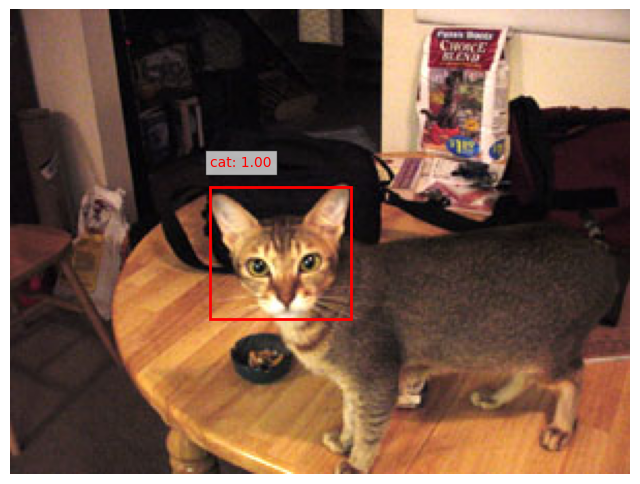

Processing: Abyssinian_202


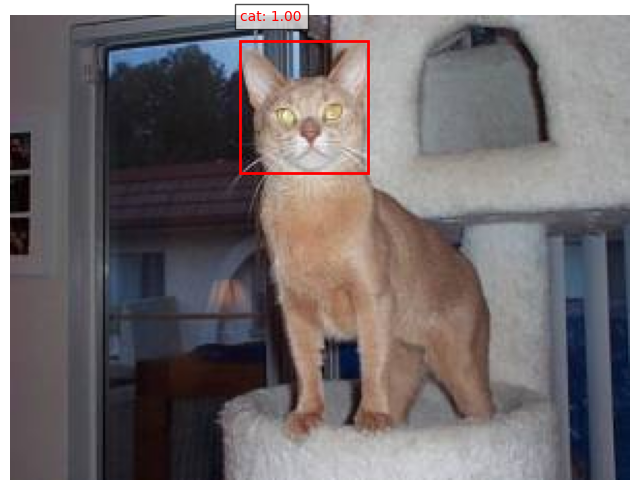

Processing: Abyssinian_204


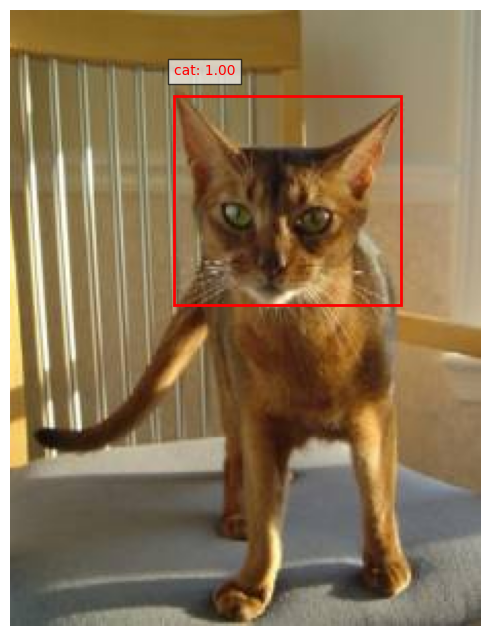

Processing: Abyssinian_205


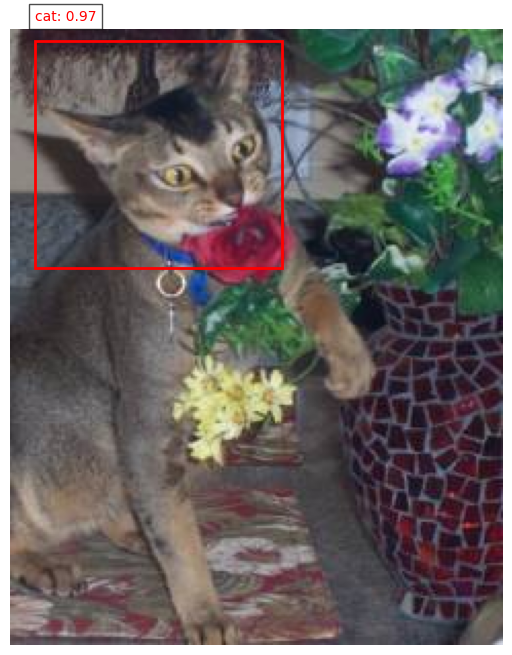

Processing: Abyssinian_206


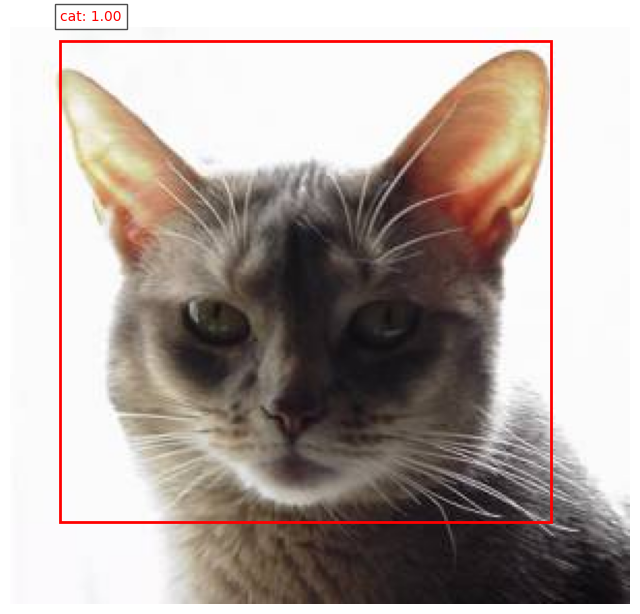

Processing: Abyssinian_207


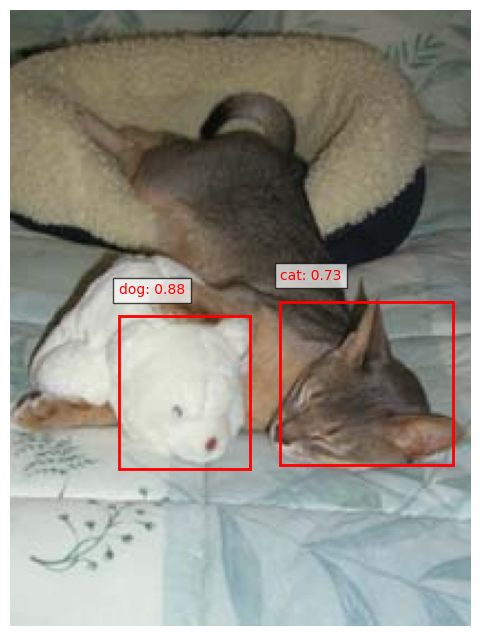

Processing: Abyssinian_20


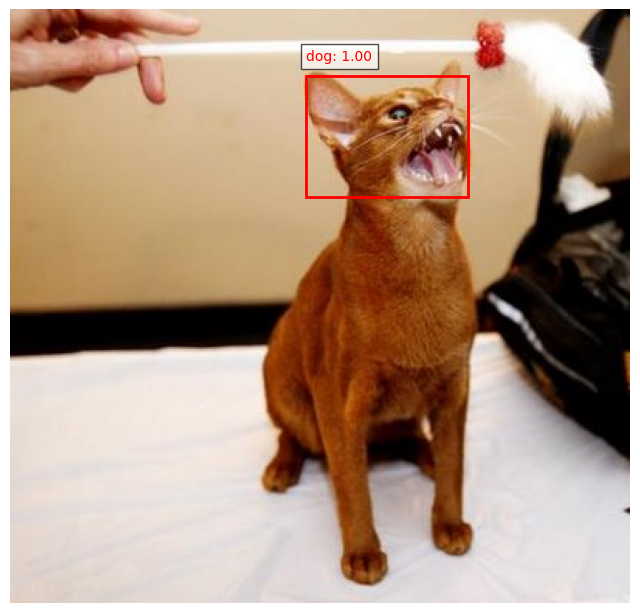

Processing: Abyssinian_210


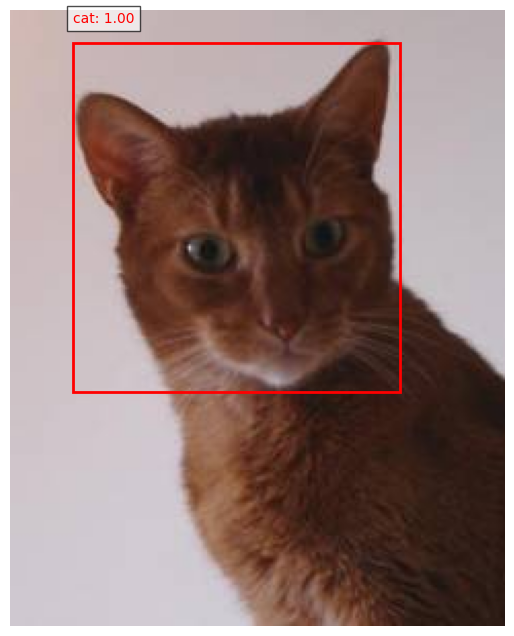

Test Inference:   0%|          | 1/459 [00:01<13:12,  1.73s/it]

Processing: Abyssinian_212


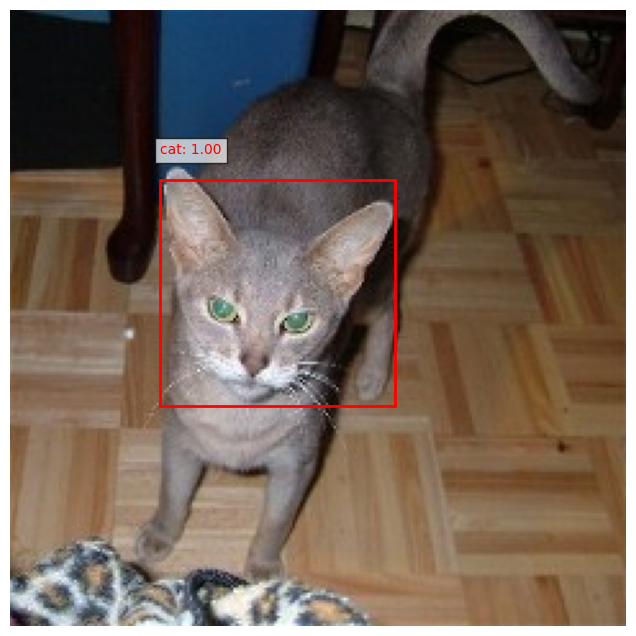

Processing: Abyssinian_213


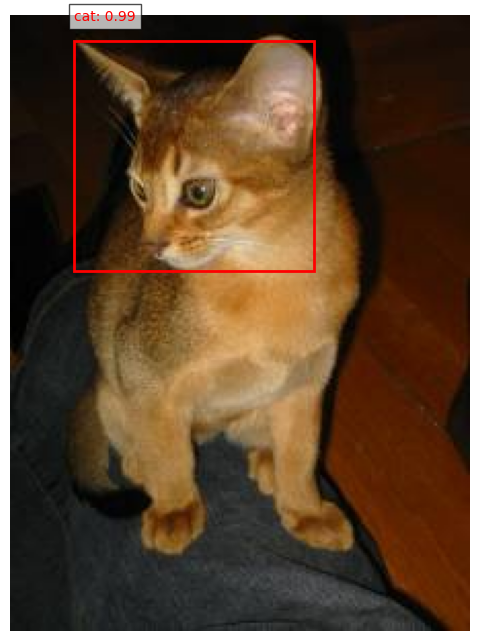

Test Inference:   0%|          | 1/459 [00:02<18:05,  2.37s/it]


In [62]:
model.eval()
max_visualizations = 10  # 최대 시각화 개수 설정
count = 0

with torch.no_grad():
    for images, image_files in tqdm(test_loader, desc="Test Inference"):
        images = [img.to(device) for img in images]
        predictions = model(images)

        for img, pred, file_name in zip(images, predictions, image_files):
            if count >= max_visualizations:
                break  # 최대 개수 초과 시 중단

            print(f"Processing: {file_name}")
            visualize_prediction(img.cpu(), pred, classes)
            count += 1

        if count >= max_visualizations:
            break  # 루프 종료